# Metodo para generar peregrinos en funcion de la prediccion y de la distribucion del cluster


In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import random

## Numero de peregrinos que vienen 

In [6]:
prediccion = pd.read_csv('prediction_oneweek.csv')
prediccion = prediccion.set_index('ds')
prediccion.index = pd.to_datetime(prediccion.index)

In [7]:
prediccion['prediction'] = round(prediccion['prediction'])

In [10]:
prediccion.prediction

ds
2022-07-04    1411.0
2022-07-05    1477.0
2022-07-06    1700.0
2022-07-07    2037.0
2022-07-08    2242.0
2022-07-09    2041.0
2022-07-10    2030.0
Name: prediction, dtype: float64

## Peregrinos etiquetados

In [11]:
clust = pd.read_csv('Treated_csv/entries_with_labels_fin.csv')
clust = clust.set_index('Fecha')
clust.index = pd.to_datetime(clust.index)

In [12]:
clust_pred = clust[(clust.Mes == 7) & (clust.Dia < 12)]

In [13]:
clust_pred = clust_pred.dropna()

In [14]:
clust_pred

,Sexo,Edad,Continente,Pais,Autonomia,Medio,Motivo,Camino,Origen,Profesion,Latitud,Longitud,Año,Mes,Dia,Dialv,Cluster
Fecha,,,,,,,,,,,,,,,,,
2010-07-01 00:00:00,M,59,Europa,España,Comunidad Valenciana,Pie,Religioso y otros,Portugues-Camino,Tui,Profesores,42.050137,-8.646641,2010,7,1,Thursday,1.0
2010-07-01 00:00:00,F,33,Europa,España,Galicia,Pie,Religioso y otros,Frances-Camino de,S. Jean P. Port,Tecnicos,43.163872,-1.229537,2010,7,1,Thursday,0.0
2010-07-01 00:00:00,M,30,Europa,España,Madrid,Pie,Religioso y otros,Frances-Camino de,Sarria,Obreros,42.778420,-7.414661,2010,7,1,Thursday,0.0
2010-07-01 00:00:00,M,42,Europa,España,Comunidad Valenciana,Pie,Religioso y otros,Frances-Camino de,Ponferrada,Profesores,42.545412,-6.593872,2010,7,1,Thursday,0.0
2010-07-01 00:00:00,M,24,Europa,España,Andalucía,Pie,Religioso,Frances-Camino de,Ponferrada,Empleados,42.545412,-6.593872,2010,7,1,Thursday,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-07-11 19:01:39,M,47,Europa,España,Murcia,Bicicleta,Religioso y otros,Norte-Camino de,Bayonne,Otros,43.494514,-1.473666,2022,7,11,Monday,1.0
2022-07-11 19:01:43,M,47,Europa,España,Murcia,Bicicleta,Religioso y otros,Norte-Camino de,Bayonne,Otros,43.494514,-1.473666,2022,7,11,Monday,1.0
2022-07-11 19:03:07,M,47,Europa,España,Castilla León,Pie,Religioso,Costa Camino Portugues,Baiona,Otros,43.494514,-1.473666,2022,7,11,Monday,1.0


## Calcular la distribución

In [15]:
clust_distribucion = stats.rv_discrete(name='clust_distribucion',
                                      values=(clust_pred['Cluster'].unique(),
                                              clust_pred['Cluster'].value_counts(normalize=True)))


In [16]:
tamano_muestra = prediccion['prediction'].sum()
tamano_muestra = tamano_muestra.astype(int)


muestras = clust_distribucion.rvs(size=tamano_muestra)



In [17]:
tamano_muestra

12938

In [18]:
len (muestras)

12938

In [19]:
clust_generado = pd.DataFrame({
    'Fecha': np.repeat(prediccion.index, prediccion['prediction']),
    'Cluster': muestras
})


In [20]:
clust_generado

,Fecha,Cluster
0,2022-07-04,1.0
1,2022-07-04,1.0
2,2022-07-04,1.0
3,2022-07-04,1.0
4,2022-07-04,0.0
...,...,...
12933,2022-07-10,2.0
12934,2022-07-10,0.0
12935,2022-07-10,1.0
12936,2022-07-10,2.0


In [21]:
grupos = clust_generado.groupby(['Fecha', 'Cluster']).size()

In [22]:
print(grupos)

Fecha       Cluster
2022-07-04  0.0        467
            1.0        570
            2.0        374
2022-07-05  0.0        478
            1.0        608
            2.0        391
2022-07-06  0.0        528
            1.0        700
            2.0        472
2022-07-07  0.0        600
            1.0        854
            2.0        583
2022-07-08  0.0        694
            1.0        905
            2.0        643
2022-07-09  0.0        607
            1.0        819
            2.0        615
2022-07-10  0.0        594
            1.0        829
            2.0        607
dtype: int64


In [23]:
467 + 570 + 374

1411

## !Coincide 1411.0 = 467 + 570 + 374!

In [24]:
grupos = pd.DataFrame(grupos)

In [25]:
grupos

0
Fecha      Cluster     
2022-07-04 0.0      467
           1.0      570
           2.0      374
2022-07-05 0.0      478
           1.0      608
           2.0      391
2022-07-06 0.0      528
           1.0      700
           2.0      472
2022-07-07 0.0      600
           1.0      854
           2.0      583
2022-07-08 0.0      694
           1.0      905
           2.0      643
2022-07-09 0.0      607
           1.0      819
           2.0      615
2022-07-10 0.0      594
           1.0      829
           2.0      607

<Axes: >

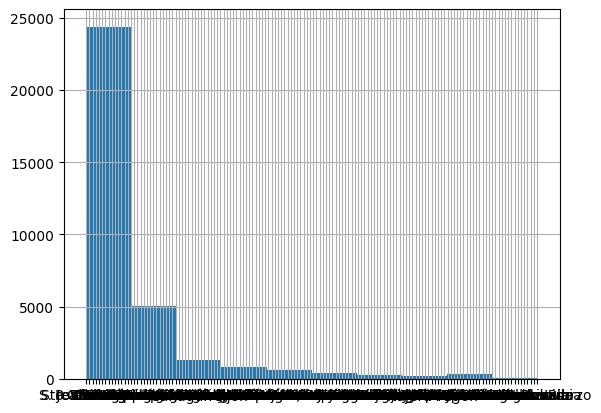

In [26]:
cluster_pred_0 = clust_pred[clust_pred.Cluster==0]
cluster_pred_1 = clust_pred[clust_pred.Cluster==1]
cluster_pred_2 = clust_pred[clust_pred.Cluster==2]
cluster_pred_0.Origen.hist()

In [27]:
cluster_pred_0['Origen'].value_counts()

Sarria             13806
Cebreiro            2529
Ferrol              1636
Ponferrada          1476
León                1288
                   ...  
Portugal               1
Lalín                  1
Gándara                1
Povoa de Varzim        1
Berducedo              1
Name: Origen, Length: 142, dtype: int64

In [28]:
origenes = cluster_pred_0['Origen']

frecuencias = cluster_pred_0['Origen'].value_counts()

lista_repetida = []
for valor, frecuencia in frecuencias.iteritems():
    lista_repetida.extend([valor] * frecuencia)


/var/folders/rv/z0yvw1vn57j7rg7v3j11b_3r0000gn/T/ipykernel_29105/643850792.py:6: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  for valor, frecuencia in frecuencias.iteritems():


In [29]:
lista_repetida

['Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',
 'Sarria',

In [30]:
clust_generado_0 = clust_generado[clust_generado.Cluster == 0]

In [31]:
clust_generado_0['Origen'] = random.choices(lista_repetida, k=len(clust_generado_0))


/var/folders/rv/z0yvw1vn57j7rg7v3j11b_3r0000gn/T/ipykernel_29105/388846253.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clust_generado_0['Origen'] = random.choices(lista_repetida, k=len(clust_generado_0))


In [32]:
clust_generado_0.to_csv('clust_generado_0.csv')

In [33]:
clust_generado_0

,Fecha,Cluster,Origen
4,2022-07-04,0.0,Astorga
5,2022-07-04,0.0,Sarria
11,2022-07-04,0.0,Povoa de Varzim
16,2022-07-04,0.0,Cebreiro
18,2022-07-04,0.0,León
...,...,...,...
12917,2022-07-10,0.0,Ferrol
12918,2022-07-10,0.0,Vega de Valcarce
12925,2022-07-10,0.0,Astorga
12926,2022-07-10,0.0,Sarria


In [37]:
clust_generado_0.Origen.value_counts()

Sarria             1594
Cebreiro            315
Ferrol              198
Ponferrada          181
León                139
                   ... 
La Mesa, España       1
Nájera                1
Valladolid            1
Castroverde           1
Mérida                1
Name: Origen, Length: 104, dtype: int64

In [38]:
origenes = cluster_pred_1['Origen']

frecuencias = cluster_pred_1['Origen'].value_counts()

lista_repetida = []
for valor, frecuencia in frecuencias.iteritems():
    lista_repetida.extend([valor] * frecuencia)
clust_generado_1 = clust_generado[clust_generado.Cluster == 1]
clust_generado_1['Origen'] = random.choices(lista_repetida, k=len(clust_generado_1))



/var/folders/rv/z0yvw1vn57j7rg7v3j11b_3r0000gn/T/ipykernel_29105/3291380491.py:6: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  for valor, frecuencia in frecuencias.iteritems():
/var/folders/rv/z0yvw1vn57j7rg7v3j11b_3r0000gn/T/ipykernel_29105/3291380491.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clust_generado_1['Origen'] = random.choices(lista_repetida, k=len(clust_generado_1))


In [39]:
clust_generado_1

,Fecha,Cluster,Origen
0,2022-07-04,1.0,Vilalba
1,2022-07-04,1.0,Fonsagrada
2,2022-07-04,1.0,Lugo
3,2022-07-04,1.0,Sevilla
7,2022-07-04,1.0,Oviedo
...,...,...,...
12927,2022-07-10,1.0,Ourense
12928,2022-07-10,1.0,Tui
12929,2022-07-10,1.0,Oporto Costa
12931,2022-07-10,1.0,Ferrol


In [40]:
origenes = cluster_pred_2['Origen']

frecuencias = cluster_pred_2['Origen'].value_counts()

lista_repetida = []
for valor, frecuencia in frecuencias.iteritems():
    lista_repetida.extend([valor] * frecuencia)
clust_generado_2 = clust_generado[clust_generado.Cluster == 2]
clust_generado_2['Origen'] = random.choices(lista_repetida, k=len(clust_generado_2))




/var/folders/rv/z0yvw1vn57j7rg7v3j11b_3r0000gn/T/ipykernel_29105/71355422.py:6: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  for valor, frecuencia in frecuencias.iteritems():
/var/folders/rv/z0yvw1vn57j7rg7v3j11b_3r0000gn/T/ipykernel_29105/71355422.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clust_generado_2['Origen'] = random.choices(lista_repetida, k=len(clust_generado_2))


In [41]:
clust_generado_2

,Fecha,Cluster,Origen
6,2022-07-04,2.0,Sarria
12,2022-07-04,2.0,Puente la Reina
14,2022-07-04,2.0,Sarria
15,2022-07-04,2.0,Ferreiros
17,2022-07-04,2.0,Sarria
...,...,...,...
12930,2022-07-10,2.0,Sarria
12932,2022-07-10,2.0,Sarria
12933,2022-07-10,2.0,Villafranca del Bierzo
12936,2022-07-10,2.0,Astorga


In [46]:
cluster_pred_con_origen =pd.DataFrame()

In [47]:
cluster_pred_con_origen = pd.concat([clust_generado_2,clust_generado_1,clust_generado_0], axis=0)

In [48]:
cluster_pred_con_origen.to_csv('origenes_generados.csv')

In [49]:
cluster_pred_con_origen

,Fecha,Cluster,Origen
6,2022-07-04,2.0,Sarria
12,2022-07-04,2.0,Puente la Reina
14,2022-07-04,2.0,Sarria
15,2022-07-04,2.0,Ferreiros
17,2022-07-04,2.0,Sarria
...,...,...,...
12917,2022-07-10,0.0,Ferrol
12918,2022-07-10,0.0,Vega de Valcarce
12925,2022-07-10,0.0,Astorga
12926,2022-07-10,0.0,Sarria


In [72]:
etaps = pd.read_excel('Caminos con etapas 2.xlsx', header= 2)
etaps = etaps.rename(columns={'Ciudad': 'Origen'})


etaps.head(2)

,Camino,Etapa,Origen,km
0,Frances,0,Santiago de Compostela,0.0
1,Frances,1,O Pedrouzo,19.4


In [73]:
def limpiar_columna(df, columna):
    df[columna] = df[columna].apply(lambda x: x.rstrip())
    return df



In [74]:
limpiar_columna(etaps,'Origen').head()

,Camino,Etapa,Origen,km
0,Frances,0,Santiago de Compostela,0.0
1,Frances,1,O Pedrouzo,19.4
2,Frances,2,Arzúa,19.3
3,Frances,3,Palas de Rei,28.5
4,Frances,4,Portomarín,24.8


In [89]:
etaps['Origen'] = [s.replace("O Cebreiro" , "Cebreiro") for s in etaps.Origen]  
etaps['Origen'] = [s.replace("S. Jean Pied Port" , "S. Jean P. Port") for s in etaps.Origen]  
etaps['Origen'] = [s.replace("Tui" , "Valença do Minho") for s in etaps.Origen]  





In [106]:
cluster_pred_con_origen['OrigenCamino'] = cluster_pred_con_origen['Origen'] + cluster_pred_con_origen['Camino']
etaps['OrigenCamino'] = etaps['Origen'] + etaps['Camino']



In [107]:
etap_dict = dict(zip(etaps['OrigenCamino'], etaps['Camino']))
etap_dict

{'Santiago de CompostelaFrances': 'Frances',
 'O PedrouzoFrances': 'Frances',
 'ArzúaFrances': 'Frances',
 'Palas de ReiFrances': 'Frances',
 'PortomarínFrances': 'Frances',
 'SarriaFrances': 'Frances',
 'TriacastelaFrances': 'Frances',
 'CebreiroFrances': 'Frances',
 'Villafranca Del BierzoFrances': 'Frances',
 'PonferradaFrances': 'Frances',
 'FoncebadónFrances': 'Frances',
 'AstorgaFrances': 'Frances',
 'San Martín Del CaminoFrances': 'Frances',
 'LeónFrances': 'Frances',
 'Mansilla De Las MulasFrances': 'Frances',
 'Bercianos Del Real CaminoFrances': 'Frances',
 'Terradillos De Los TemplariosFrances': 'Frances',
 'Carrión De Los CondesFrances': 'Frances',
 'FrómistaFrances': 'Frances',
 'CastrojerizFrances': 'Frances',
 'Hornillos Del CaminoFrances': 'Frances',
 'BurgosFrances': 'Frances',
 'San Juan De OrtegaFrances': 'Frances',
 'BeloradoFrances': 'Frances',
 'Santo Domingo de La CalzadaFrances': 'Frances',
 'NájeraFrances': 'Frances',
 'LogroñoFrances': 'Frances',
 'Los ArcosFra

In [108]:
cluster_pred_con_origen['Camino'] = cluster_pred_con_origen['OrigenCamino'].map(etap_dict)

cluster_pred_con_origen[cluster_pred_con_origen.Camino.isna()].Origen.value_counts()

Tui                      1644
S. Jean P. Port           218
Vilafranca                155
Asturias                  129
Madrid                    113
                         ... 
Gondarém                    1
Faro                        1
As Gándaras de Budiño       1
Jaén                        1
Cacabelos                   1
Name: Origen, Length: 116, dtype: int64

In [109]:
cluster_pred_con_origen.loc[cluster_pred_con_origen['Origen'] == 'Tui', 'Camino'] = 'Portugues'
cluster_pred_con_origen.loc[cluster_pred_con_origen['Origen'] == 'S. Jean P. Port', 'Camino'] = 'Frances'
cluster_pred_con_origen.loc[cluster_pred_con_origen['Origen'] == 'Vilafranca', 'Camino'] = 'Frances'

In [111]:
cluster_pred_con_origen[cluster_pred_con_origen.Camino.isna()].Origen.value_counts()

Asturias                     129
Madrid                       113
Porriño                      111
Cruz de Ferro                 83
Sevilla                       76
                            ... 
Lourdes                        1
Las Herrerías de Valcarce      1
Faro                           1
Entrimo                        1
Cacabelos                      1
Name: Origen, Length: 113, dtype: int64

In [112]:
etap_dict2 = dict(zip(etaps['OrigenCamino'], etaps['Etapa']))
etap_dict2

{'Santiago de CompostelaFrances': 0,
 'O PedrouzoFrances': 1,
 'ArzúaFrances': 2,
 'Palas de ReiFrances': 3,
 'PortomarínFrances': 4,
 'SarriaFrances': 5,
 'TriacastelaFrances': 6,
 'CebreiroFrances': 7,
 'Villafranca Del BierzoFrances': 8,
 'PonferradaFrances': 9,
 'FoncebadónFrances': 10,
 'AstorgaFrances': 11,
 'San Martín Del CaminoFrances': 12,
 'LeónFrances': 13,
 'Mansilla De Las MulasFrances': 14,
 'Bercianos Del Real CaminoFrances': 15,
 'Terradillos De Los TemplariosFrances': 16,
 'Carrión De Los CondesFrances': 17,
 'FrómistaFrances': 18,
 'CastrojerizFrances': 19,
 'Hornillos Del CaminoFrances': 20,
 'BurgosFrances': 21,
 'San Juan De OrtegaFrances': 22,
 'BeloradoFrances': 23,
 'Santo Domingo de La CalzadaFrances': 24,
 'NájeraFrances': 25,
 'LogroñoFrances': 26,
 'Los ArcosFrances': 27,
 'EstellaFrances': 28,
 'Puente la ReinaFrances': 29,
 'PamplonaFrances': 30,
 'ZubiriFrances': 31,
 'RoncesvallesFrances': 32,
 'Saint Jean Pied de PortFrances': 33,
 'Santiago de Compost

In [113]:
cluster_pred_con_origen['Etapa'] = cluster_pred_con_origen['OrigenCamino'].map(etap_dict2)



In [116]:
cluster_pred_con_origen.Etapa.isna().value_counts()

False    9186
True     3752
Name: Etapa, dtype: int64

In [117]:
cluster_pred_con_origen[cluster_pred_con_origen.Etapa.isna()].Origen.value_counts()

Tui                      1644
S. Jean P. Port           218
Vilafranca                155
Asturias                  129
Madrid                    113
                         ... 
Gondarém                    1
Faro                        1
As Gándaras de Budiño       1
Jaén                        1
Cacabelos                   1
Name: Origen, Length: 116, dtype: int64

In [118]:
cluster_pred_con_origen.loc[cluster_pred_con_origen['Origen'] == 'Tui', 'Etapa'] = 6
cluster_pred_con_origen.loc[cluster_pred_con_origen['Origen'] == 'S. Jean P. Port', 'Etapa'] = 33
cluster_pred_con_origen.loc[cluster_pred_con_origen['Origen'] == 'Vilafranca', 'Etapa'] = 8

In [120]:
cluster_pred_con_origen

,Fecha,Cluster,Origen,Camino,OrigenCamino,Etapa
6,2022-07-04,2.0,Sarria,Frances,SarriaFrances,5.0
12,2022-07-04,2.0,Puente la Reina,Frances,Puente la ReinaFrances,29.0
14,2022-07-04,2.0,Sarria,Frances,SarriaFrances,5.0
15,2022-07-04,2.0,Ferreiros,NaN,NaN,NaN
17,2022-07-04,2.0,Sarria,Frances,SarriaFrances,5.0
...,...,...,...,...,...,...
12917,2022-07-10,0.0,Ferrol,Ingles,FerrolIngles,6.0
12918,2022-07-10,0.0,Vega de Valcarce,NaN,NaN,NaN
12925,2022-07-10,0.0,Astorga,Frances,AstorgaFrances,11.0
12926,2022-07-10,0.0,Sarria,Frances,SarriaFrances,5.0
